In [32]:
import numpy as np
from dataclasses import dataclass
import xml.etree.ElementTree as ET
from xml.dom import minidom
import time
import mujoco
import mujoco.viewer
from pathlib import Path
import argparse
import plots_functions as pf
import importlib
importlib.reload(pf)

<module 'plots_functions' from 'c:\\Manoj\\Mtech_project\\V1\\plots_functions.py'>

In [10]:
# ============================================================
# DIFFERENT TENDON
# ============================================================
@dataclass
class Tendon:
    """
    General tendon routing.
    rho(s) tendon position in local backbone frame
    rho_s(s) spatial derivative of rho
    rho_ss(s)second spatial derivative of rho
    tension(t) time-varying tendon tension
    """
    rho: callable
    rho_s: callable
    rho_ss: callable
    tension: callable
    name: str = "tendon"

# ============================================================
# TENDON ROUTING FUNCTIONS 
# ============================================================
def make_general_tendon(rho, rho_s, rho_ss, tension_function,  name="tendon"):
    return Tendon(rho=rho, rho_s=rho_s, rho_ss=rho_ss,
        tension=tension_function, name=name)

def make_helical_tendon(L, radius, turns, tension_function, phase=0.0, name="helical"):
    """
    General helical tendon routing.
        rho(s) = [r cos(phi), r sin(phi), 0]
        phi(s) = 2*pi*turns*s/L + phase
    """
    phi = (2.0* np.pi* turns* s/ L+ phase)
    phi_s = (2.0* np.pi* turns/ L)
    def rho(s):
        return np.array([radius * np.cos(phi), radius * np.sin(phi), 0.0])
    
    def rho_s(s):
        return np.array([-radius* np.sin(phi)* phi_s, radius* np.cos(phi)* phi_s, 0.0])

    def rho_ss(s):
        return np.array([-radius* np.cos(phi)* phi_s**2, -radius* np.sin(phi)* phi_s**2, 0.0])

    return Tendon(rho=rho,rho_s=rho_s,rho_ss=rho_ss, tension=tension_function,name=name)


def make_straight_tendon(radius, angle, tension_function, name="straight"):
    """Straight tendon at constant offset.angle is in radians."""

    rho_const = np.array([radius * np.cos(angle), radius * np.sin(angle), 0.0])
    def rho(s):return rho_const.copy()
    def rho_s(s):return np.zeros(3)
    def rho_ss(s): return np.zeros(3)
    return Tendon(rho=rho, rho_s=rho_s, rho_ss=rho_ss, tension=tension_function, name=name)

In [5]:
# ============================================================
# COSSERAT AND KIRCHHOFF MODEL
# ============================================================
import Cosserat_Kirchhoff_solvers as DCK


In [14]:
# ============================================================
# OPENCR MUJOCO MODEL UNIVERSITY OF TORONTO
# ============================================================
import OpenCR_mujoco as OCRM

In [ ]:
# ============================================================
# PRBM MUJOCO MODEL ANANTHASURESH IISc MECHANICAL ENGINEERING
# ============================================================
"""
1R Pseudo-Rigid-Body Model.
Dr Ananthasuresh IISc Mechanical Engineering:
    s_h = L/6
    L_rot = 5L/6

Nonlinear dynamics:
    I*alpha_ddot - m*g*l_g*sin(alpha)
    + C*alpha_dot + K*alpha = u

State:
    q = [alpha]
    q_dot = [alpha_dot]
"""
import PRBM as PRBM

In [11]:
# ============================================================
# MISC
# ============================================================
def hat(x):
    """Skew-symmetric matrix such that hat(x) @ y = x cross y"""
    x1, x2, x3 = x
    return np.array([[0.0, -x3,  x2], [x3,  0.0, -x1], [-x2, x1,  0.0]])

def orthonormalize(R):
    """Project a numerically drifted matrix onto SO(3)."""
    U, _, Vt = np.linalg.svd(R)
    Rproj = U @ Vt

    if np.linalg.det(Rproj) < 0.0: U[:, -1] *= -1.0; Rproj = U @ Vt
    return Rproj

def position_error_percent(p_ref, p_model, L):
    return 100.0*np.linalg.norm(p_model-p_ref)/L

def centerline_error_percent(P_ref, P_model, L):
    err = np.linalg.norm(P_model-P_ref, axis=1)
    return 100.0*np.sqrt(np.mean(err**2))/L

def orientation_error_deg(R_ref, R_model):
    Re = R_ref.T @ R_model
    c = np.clip((np.trace(Re)-1.0)/2.0,-1.0,1.0)
    return np.degrees(np.arccos(c))

def compare_model_to_reference(ref, model, q_ref, q_model, s_grid, L):
    P_ref = np.array([ref.pose(s,q_ref)[:3,3] for s in s_grid])
    P_model = np.array([model.pose(s,q_model)[:3,3] for s in s_grid])

    T_ref = ref.pose(L,q_ref)
    T_model = model.pose(L,q_model)

    ep = position_error_percent(T_ref[:3,3],T_model[:3,3],L)
    erms = centerline_error_percent(P_ref,P_model,L)
    eo = orientation_error_deg(T_ref[:3,:3],T_model[:3,:3])

    return {
        "tip_position_error_percent": ep,
        "centerline_RMS_error_percent": erms,
        "tip_orientation_error_deg": eo
    }
# ============================================================
# MISC
# ============================================================
def hat(x):
    """Skew-symmetric matrix such that hat(x) @ y = x cross y"""
    x1, x2, x3 = x
    return np.array([[0.0, -x3,  x2], [x3,  0.0, -x1], [-x2, x1,  0.0]])

def orthonormalize(R):
    """Project a numerically drifted matrix onto SO(3)."""
    U, _, Vt = np.linalg.svd(R)
    Rproj = U @ Vt

    if np.linalg.det(Rproj) < 0.0: U[:, -1] *= -1.0; Rproj = U @ Vt
    return Rproj

def position_error_percent(p_ref, p_model, L):
    return 100.0*np.linalg.norm(p_model-p_ref)/L

def centerline_error_percent(P_ref, P_model, L):
    err = np.linalg.norm(P_model-P_ref, axis=1)
    return 100.0*np.sqrt(np.mean(err**2))/L

def orientation_error_deg(R_ref, R_model):
    Re = R_ref.T @ R_model
    c = np.clip((np.trace(Re)-1.0)/2.0,-1.0,1.0)
    return np.degrees(np.arccos(c))

def compare_model_to_reference(ref, model, q_ref, q_model, s_grid, L):
    P_ref = np.array([ref.pose(s,q_ref)[:3,3] for s in s_grid])
    P_model = np.array([model.pose(s,q_model)[:3,3] for s in s_grid])

    T_ref = ref.pose(L,q_ref)
    T_model = model.pose(L,q_model)

    ep = position_error_percent(T_ref[:3,3],T_model[:3,3],L)
    erms = centerline_error_percent(P_ref,P_model,L)
    eo = orientation_error_deg(T_ref[:3,:3],T_model[:3,:3])

    return {
        "tip_position_error_percent": ep,
        "centerline_RMS_error_percent": erms,
        "tip_orientation_error_deg": eo
    }


In [12]:
# ROBOT PARAMETERS
L = 0.40
E = 175e6
mu = 0.45
G = E/2/(1+mu)
radius = 0.006
A=np.pi*radius**2
density = 200.0
m = density * A * L
gravity = np.array([0.0, 0.0, -9.81])
I=np.pi*(radius**4/4)
N = 8
ds = L / N
# TIME
dt = 0.05
t_final = 3
time_array = np.arange(0.0, t_final + dt, dt)

# GENERAL TENDON ROUTING (Three straight tendons at 120 degrees)
tendon_radius = 0.012
n_tendons = 3

# Setup Tendons for current loading condition
A1 = 0.0
A2 = 2.0 * np.pi / 3.0
A3 = 4.0 * np.pi / 3.0

# CONFIGURATION
config = {
    "description": "My TDCR robot",
    "num_segments": 1,
    "links_per_segment": {"1": N},
    "segment_lengths": {"1": L},
    "total_links": N,
    "total_length": L,
    "radius": radius,
    "mass": m,
    # -------------------------------------------------------
    # 3 rotational DOF per link
    # --------------------------------------------------------
    "joints_per_link": 3,
    "joint_config_mode": "material",
    # --------------------------------------------------------
    # Material
    # --------------------------------------------------------
    "material_properties": {
        "density": density,
        "youngs_modulus": E,
        "poisson_ratio": mu,
        "inner_radius": 0.0,
        "outer_radius": radius
    },
    # --------------------------------------------------------
    # Tendon actuation
    # --------------------------------------------------------
    "actuation_mode": "parallel_tendons",
    "actuator_type": "motor",
    "actuation_details": {
        "segments": [{
                "number_of_tendons": n_tendons,
                "distance_to_backbone": tendon_radius
            }]
    },
    # --------------------------------------------------------
    # Segment tendon angular offsets
    # --------------------------------------------------------
    "segment_angle_offsets": [0.0],
    # --------------------------------------------------------
    # Tendon actuator properties
    # --------------------------------------------------------
    "actuator_properties": {
        "tendon_actuator_type": "motor",
        "tendon_forcelimited": "true",
        "tendon_forcerange": "-100 0",
        "tendon_pretension": 0.0,
        "tendon_constraint_factor": 1.0,
    },
    # --------------------------------------------------------
    # Joint damping
    # --------------------------------------------------------
    "joint_damping": 0.05,
    # --------------------------------------------------------
    # MuJoCo
    # --------------------------------------------------------
    "gravity": "0 0 0",
    "disable_self_collision": True,
    "plane": False,
    "link_shape": "cylinder"
}
OCRm.generate_tdcr_xml_from_config(config, output_filename=r"C:\Manoj\Mtech_project\opencr-mujoco\mujoco_xml\1seg_tdcr.xml")


TDCR MuJoCo XML GENERATED
Output       : C:\Manoj\Mtech_project\opencr-mujoco\mujoco_xml\1seg_tdcr.xml
Segments     : 1
Total links  : 8
Total length : 0.400000 m
E            : 1.750000e+08 Pa
nu           : 0.450000
G            : 6.034483e+07 Pa
Radius       : 0.006000 m
Ixx = Iyy    : 1.017876e-09 m^4
J            : 2.035752e-09 m^4

SEGMENT PARAMETERS
----------------------------------------------------------------------
Segment 1
  Ls        = 0.400000 m
  N         = 8
  li        = 0.050000 m
  kx        = 3.56256606917 N*m/rad
  ky        = 3.56256606917 N*m/rad
  kz        = 2.45694211667 N*m/rad
  link mass = 0.00113097335529 kg


In [34]:
# ============================================================
# 7. MAIN
# ============================================================
#if __name__ == "__main__":

# TENDON TENSIONS
def pulse(t,t_on,t_off,T=10.0,tau=0.02): return 0.5*T*(np.tanh((t-t_on)/tau)-np.tanh((t-t_off)/tau))
def T1(t): return 50/6*t*2#10 if t > t_final/2 else 0#pulse(t,0.0,2/3)+pulse(t,2.0,8/3) #10*(np.cos(np.pi*t)) if np.cos(np.pi*t) > 0 else 0# 10*abs(np.sin(np.pi*t))#
def T2(t): return 0.0 #pulse(t,2/3,4/3)+pulse(t,8/3,10/3) #10*(np.sin(np.pi*t)) if np.sin(np.pi*t) > 0 else 0#
def T3(t): return 0.0 #pulse(t,4/3,2.0)+pulse(t,10/3,4.0) #10*(np.cos(np.pi+np.pi*t)) if np.cos(np.pi+np.pi*t) > 0 else 0#
tension_func = [T1,T2,T3]

tendon_1 = make_straight_tendon(radius=tendon_radius, angle=A1, tension_function=tension_func[0], name="Tendon 1")
tendon_2 = make_straight_tendon(radius=tendon_radius, angle=A2, tension_function=tension_func[1], name="Tendon 2")
tendon_3 = make_straight_tendon(radius=tendon_radius, angle=A3, tension_function=tension_func[2], name="Tendon 3")

positions = np.array([tendon_1.rho(0.0)[:2], tendon_2.rho(0.0)[:2], tendon_3.rho(0.0)[:2]])
tendons = [tendon_1, tendon_2, tendon_3]

def tension_vector(t):
    return np.array([tendon.tension(t) for tendon in tendons],dtype=float)

# KIRCHHOFF ROD SOLVER
k_rod = DCK.DynamicCosserat_Kirchhoff(L=L, E=E, G=G, radius=radius, density=density, crt=False)
k_solver = DCK.DynamicCosseratSolver(rod=k_rod, tendons=tendons, dt=dt, gravity=np.zeros(3),
    tip_force=np.array([0,0,0]), tip_moment=np.zeros(3), rtol=1e-6, atol=1e-6,  max_step=ds)

# COSSERAT ROD SOLVER
c_rod = DCK.DynamicCosserat_Kirchhoff(L=L, E=E, G=G, radius=radius, density=density, crt=True)
c_solver = DCK.DynamicCosseratSolver(rod=c_rod, tendons=tendons, dt=dt, gravity=gravity,
        tip_force=np.array([0,0,0]), tip_moment=np.zeros(3), rtol=1e-6, atol=1e-6,  max_step=ds)

# OPENCR MUJOCO
parser = argparse.ArgumentParser()
parser.add_argument("--xml", default=r"C:\Manoj\Mtech_project\opencr-mujoco\mujoco_xml\1seg_tdcr.xml")
parser.add_argument("--seconds", type=float, default=60.0)
args, unknown = parser.parse_known_args()
model, data = OCRM.load_model(args.xml)
act_ids = OCRM.get_actuator_ids(model)

# PRBM2R Ananthasuresh IISc
prbm = PRBM.PRBM2R(L=L,r=radius, m=m, E=E, C=0.05, g=0, moment_arms=positions)
results_prbm = prbm.simulate(t_span=(0.0,t_final), x0=[0.0,0.0,0.0,0.0], dt=dt, tensions=tension_vector)

# KIRCHHOFF ROD THEORY
# Point moment
result1 = k_solver.simulate(time_array=time_array, num_points=N, print_progress=False,dt=False,g=False,pm=True)
# Point moment with gravity
#result2 = k_solver.simulate(time_array=time_array, num_points=N, print_progress=False,dt=False,g=True, pm=True)
# Distributed load
result3 = k_solver.simulate(time_array=time_array, num_points=N, print_progress=False,dt=True, g=False,pm=False)
# Distributed load with gravity
#result4 = k_solver.simulate(time_array=time_array, num_points=N, print_progress=False,dt=True, g=True, pm=False)

# COSSERAT ROD THEORY
# Point moment
result5 = c_solver.simulate(time_array=time_array, num_points=N, print_progress=False,dt=False,g=False,pm=True)
# Point moment with gravity
#result6 = c_solver.simulate(time_array=time_array, num_points=N, print_progress=False,dt=False,g=True, pm=True)
# Distributed load
result7 = c_solver.simulate(time_array=time_array, num_points=N, print_progress=False,dt=True, g=False,pm=False)
# Distributed load with gravity
#result8 = c_solver.simulate(time_array=time_array, num_points=N, print_progress=False,dt=True, g=True, pm=False)

# MuJoCo controller
controller = OCRM.FlexibleTendonController(num_actuators=model.nu, step=0.2, maximum=100, tension_funcs=tension_func)
with mujoco.viewer.launch_passive(model, data, key_callback=controller.key_callback) as viewer:
    result9 = OCRM.forward_dynamics_interactive(model, data, viewer, controller, act_ids, t_final=t_final)

#results2 = [result2, result4, result6, result8]
#labels2  = ["K_pm_g", "K_dist_g", "Csrt_pm_g", "Csrt_dist_g"]


    

MuJoCo Model Loaded: nq=24, nv=24, nu=3, ntendon=3
Actuators: ['seg_0_ten_0', 'seg_0_ten_1', 'seg_0_ten_2']


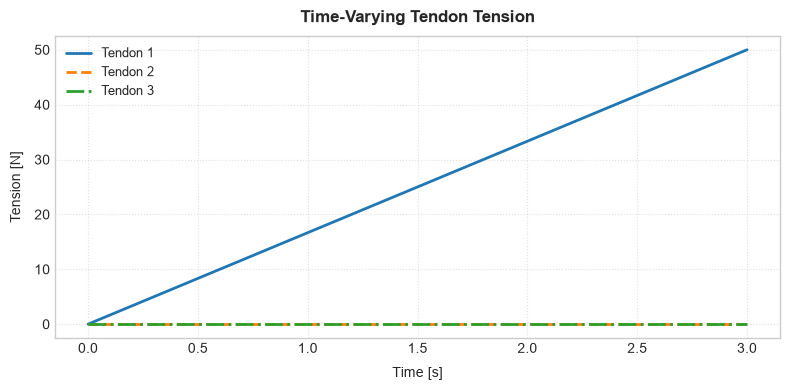

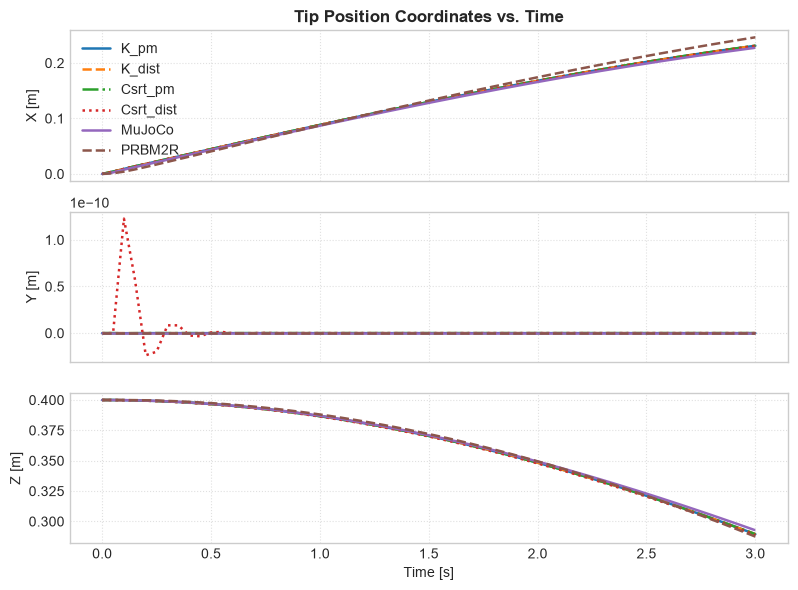

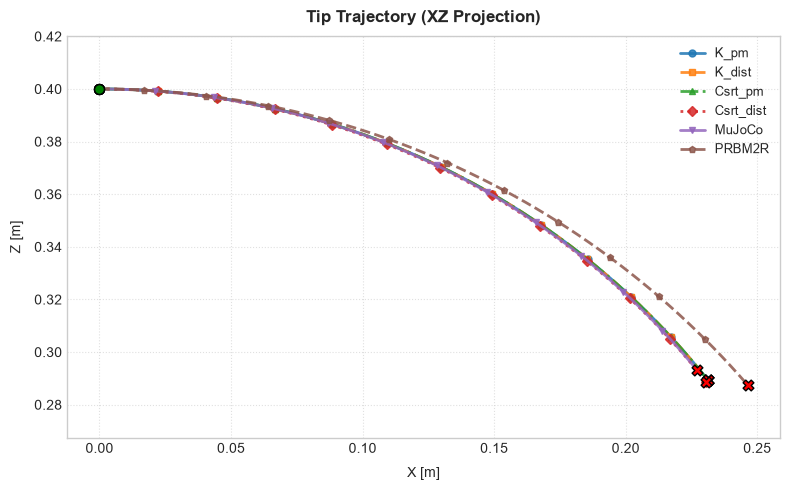

In [35]:
results  = [result1, result3, result5, result7, result9, results_prbm]
labels   = ["K_pm", "K_dist","Csrt_pm","Csrt_dist","MuJoCo", "PRBM2R"] 

results3  = [result1,results_prbm]
labels3   = ["K_pm", "PRBM2R"] 
# Initialize the plotter instance from plots_functions (pf)

plotter = pf.Plots()

# Instance method calls (prefixed with `plotter.`)
plotter.plot_tensions(result1["time"], tendons)
plotter.plot_tip_coordinates(results, labels)

# FIXED: Prefixed plot_tip_trajectory2 with `plotter.`
plotter.plot_tip_trajectory2(results, labels)

# Optional calls (uncommented examples):
# plotter.plot_tip_phase_portraits(results3, labels3)
# plotter.plot_backbone_snapshots(results, labels)
# plotter.plot_tip_trajectory(results, labels)
# plotter.plot_tip_trajectory3(results, labels, plane="XY")
# plotter.plot_internal_wrench_snapshots(results3, labels3)
# plotter.plot_internal_wrench_time_history(results3, labels3)

 Running Simulation Case: Step Load
MuJoCo Model Loaded: nq=24, nv=24, nu=3, ntendon=3
Actuators: ['seg_0_ten_0', 'seg_0_ten_1', 'seg_0_ten_2']
Plotting results for loading condition: Step Load


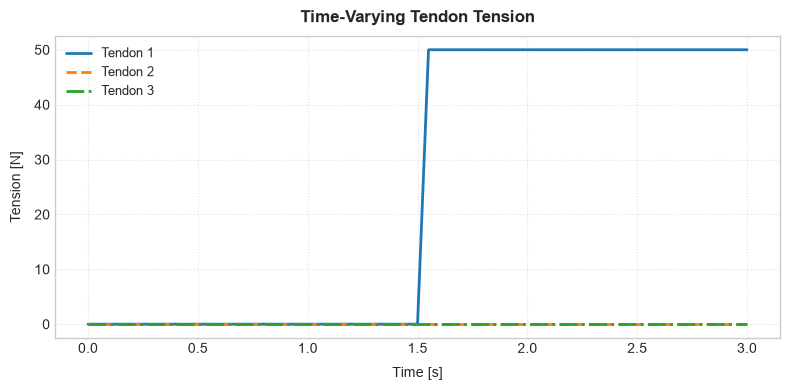

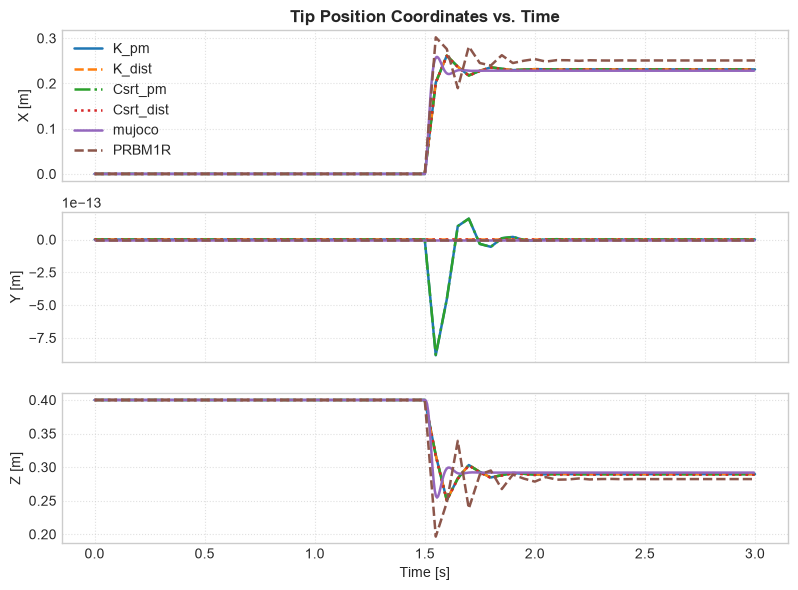

 Running Simulation Case: Linear Ramp
MuJoCo Model Loaded: nq=24, nv=24, nu=3, ntendon=3
Actuators: ['seg_0_ten_0', 'seg_0_ten_1', 'seg_0_ten_2']


In [ ]:
# ============================================================
# 7. MAIN
# ============================================================

amp=50.0  # Maximum tension amplitude for loading conditions
# DEFINE DIFFERENT LOADING CONDITIONS
load_cases = {
    "Step Load": [
        lambda t: amp if t >t_final/2 else 0.0,
        lambda t: 0.0,
        lambda t: 0.0
    ],
    "Linear Ramp": [
        lambda t: amp/t_final * t,
        lambda t: 0.0,
        lambda t: 0.0
    ],
    "Parabolic Ramp": [
        lambda t: (amp/t_final**2) * t**2,
        lambda t: 0.0,
        lambda t: 0.0
    ],
    "Sinusoidal Loading": [
        lambda t: amp * np.abs(np.sin(np.pi * t)),
        lambda t: 0.0,
        lambda t: 0.0
    ],

    "Multi Step Load": [
        lambda t: amp if t >t_final/2 else 0.0,
        lambda t: amp if t >t_final/2 else 0.0,
        lambda t: 0.0
    ],
    "Multi Linear Ramp": [
        lambda t: amp/t_final * t,
        lambda t: amp/t_final * t,
        lambda t: 0.0
    ],
    "Multi Parabolic Ramp": [
        lambda t: (amp/t_final**2) * t**2,
        lambda t: (amp/t_final**2) * t**2,
        lambda t: 0.0
    ],
    "Multi Sinusoidal Loading": [
        lambda t: amp * np.abs(np.sin(np.pi * t)),
        lambda t: amp * np.abs(np.sin(np.pi * t)),
        lambda t: 0.0
    ],
    "Multi Cos Actuation": [
        lambda t: amp * np.abs(np.cos(np.pi * t)),
        lambda t: amp * np.abs(np.cos(np.pi * t)),
        lambda t: 0.0
    ],
    "Multi Vary Step Load": [
        lambda t: amp if t < t_final/3 else 0.0,
        lambda t: amp if 2*t_final/3 > t > t_final/3 else 0.0,
        lambda t: amp if t_final > t > 2*t_final/3 else 0.0,
    ],
    "Multi-Tendon Actuation": [
        lambda t: amp * np.abs(np.sin(np.pi * t)) if t <= 1 else 0.0,
        lambda t: amp * np.abs(np.sin(np.pi * t)) if 1 < t <= 2 else 0.0,
        lambda t: amp * np.abs(np.sin(np.pi * t)) if 2 < t <= 3 else 0.0
    ],
    "Multi COS_SIN Actuation": [
        lambda t: amp * np.abs(np.cos(np.pi * t)),
        lambda t: amp * np.abs(np.sin(np.pi * t)),
        lambda t: 0.0
    ],
    
}

# Dict to store trajectory comparison results across load cases
all_case_results = {}

# Iterate over each loading condition to observe model behaviors
for case_name, tension_func in load_cases.items():
    print(f" Running Simulation Case: {case_name}")
    
    # 1. Setup Tendons for current loading condition
    tendon_1 = make_straight_tendon(radius=tendon_radius, angle=A1, tension_function=tension_func[0], name="Tendon 1")
    tendon_2 = make_straight_tendon(radius=tendon_radius, angle=A2, tension_function=tension_func[1], name="Tendon 2")
    tendon_3 = make_straight_tendon(radius=tendon_radius, angle=A3, tension_function=tension_func[2], name="Tendon 3")
    tendons = [tendon_1, tendon_2, tendon_3]

    # 2. SOLVER
    # KIRCHHOFF ROD SOLVER
    k_rod = DCK.DynamicCosserat_Kirchhoff(L=L, E=E, G=G, radius=radius, density=density, crt=False)
    k_solver = DCK.DynamicCosseratSolver(rod=k_rod, tendons=tendons, dt=dt, gravity=np.zeros(3),
        tip_force=np.array([0,0,0]), tip_moment=np.zeros(3), rtol=1e-6, atol=1e-6,  max_step=ds)

    # COSSERAT ROD SOLVER
    c_rod = DCK.DynamicCosserat_Kirchhoff(L=L, E=E, G=G, radius=radius, density=density, crt=True)
    c_solver = DCK.DynamicCosseratSolver(rod=c_rod, tendons=tendons, dt=dt, gravity=gravity,
            tip_force=np.array([0,0,0]), tip_moment=np.zeros(3), rtol=1e-6, atol=1e-6,  max_step=ds)

    # OPENCR MUJOCO
    parser = argparse.ArgumentParser()
    parser.add_argument("--xml", default=r"C:\Manoj\Mtech_project\opencr-mujoco\mujoco_xml\1seg_tdcr.xml")#"C:/Manoj/Mtech_project/mujoco_xml/test1.xml")
    parser.add_argument("--seconds", type=float, default=60.0)
    args, unknown = parser.parse_known_args()
    model, data = OCRM.load_model(args.xml)
    act_ids = OCRM.get_actuator_ids(model)

    # 3. RESULTS BY EACH
    # KIRCHHOFF ROD THEORY
    # Point moment
    result1 = k_solver.simulate(time_array=time_array, num_points=N, print_progress=False,dt=False,g=False,pm=True)
    # Point moment with gravity
    #result2 = k_solver.simulate(time_array=time_array, num_points=N, print_progress=False,dt=False,g=True, pm=True)
    # Distributed load
    result3 = k_solver.simulate(time_array=time_array, num_points=N, print_progress=False,dt=True, g=False,pm=False)
    # Distributed load with gravity
    #result4 = k_solver.simulate(time_array=time_array, num_points=N, print_progress=False,dt=True, g=True, pm=False)

    # COSSERAT ROD THEORY
    # Point moment
    result5 = c_solver.simulate(time_array=time_array, num_points=N, print_progress=False,dt=False,g=False,pm=True)
    # Point moment with gravity
    #result6 = c_solver.simulate(time_array=time_array, num_points=N, print_progress=False,dt=False,g=True, pm=True)
    # Distributed load
    result7 = c_solver.simulate(time_array=time_array, num_points=N, print_progress=False,dt=True, g=False,pm=False)
    # Distributed load with gravity
    #result8 = c_solver.simulate(time_array=time_array, num_points=N, print_progress=False,dt=True, g=True, pm=False)
        
    # OPENCR MUJOCO controller
    controller = OCRM.FlexibleTendonController(num_actuators=model.nu, step=0.2, maximum=100, tension_funcs=tension_func)
    with mujoco.viewer.launch_passive(model, data, key_callback=controller.key_callback) as viewer:
        result9 = OCRM.forward_dynamics_interactive(model, data, viewer, controller, act_ids, t_final=t_final)

    # PRBM1R Ananthasuresh IISc
    def tension_vector(t):
        return np.array([tendon.tension(t) for tendon in tendons],dtype=float)
    
    prbm = PRBM.PRBM2R(L=L,r=radius, m=m, E=E, C=0.01, g=0, moment_arms=positions)
    results_prbm = prbm.simulate(t_span=(0.0,t_final), x0=[0.0,0.0,0.0,0.0], dt=dt, tensions=tension_vector)

    results_no_gravity  = [result1, result3, result5, result7, result9, results_prbm]
    labels_no_gravity   = ["K_pm", "K_dist","Csrt_pm","Csrt_dist","mujoco", "PRBM1R"]
    results3  = [result1, result3, result5, result7, results_prbm]
    labels3   = ["K_pm", "K_dist","Csrt_pm","Csrt_dist", "PRBM1R"]

    #results_with_gravity = [res_K_dist, res_Csrt_dist, result_sorosim]
    #labels_with_gravity  = ["Kirchhoff (Distributed)", "Cosserat (Distributed)", "SoRoSim"]

    # Store results for comparative summaries
    all_case_results[case_name] = {
        "no_g": (results_no_gravity, labels_no_gravity),
        #"with_g": (results_with_gravity, labels_with_gravity)
    }

    # Plot individual tip trajectories and backbone curves for this specific load case
    print(f"Plotting results for loading condition: {case_name}")
    plotter = pf.Plots()
    plotter.plot_tensions(result1["time"], tendons)
    plotter.plot_tip_coordinates(results_no_gravity, labels_no_gravity)
    #plotter.plot_tip_phase_portraits(results3, labels3)
    #plotter.plot_internal_wrench_snapshots(results3, labels3)
    #plotter.plot_internal_wrench_time_history(results3, labels3)
    #plotter.plot_tip_trajectory(results_no_gravity, labels_no_gravity)
    #plotter.plot_tip_trajectory2(results_no_gravity, labels_no_gravity, plane="XZ")
    #plotter.plot_tip_trajectory2(results_no_gravity, labels_no_gravity, plane="XY")
    #plotter.plot_backbone_snapshots(results_no_gravity, labels_no_gravity)